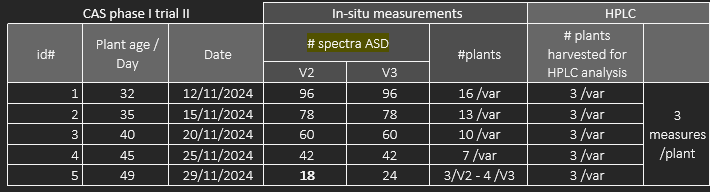

Dans le fichier il y a 3 matrices :
-	Sp_CAS2_D2D6 : ce sont les spectres (tu peux cropper entre les colonnes 31 et 1451 inclus pour restreindre la gamme spectrale), 594 observations
-	Design_mat : contient 3 colonnes qui correspondent à l’identification des 594 spectres, les colonnes sont variété|plant|date
o	Variété prend les valeurs 2 et 3
o	Plant entre 1 et 15
o	Date entre 2 et 6
-	hplc_msort : ce sont les mesures HPLC, 31 observations et les colonnes sont variété|plant|date|mad|asiat|madAc|asiatAc|TTP
o	|mad|asiat|madAc|asiatAc : ce sont les 4 molécules d’intérêt (abrégée ), à prédire séparément
o	TTP est le total de ces molécules en %, à prédire également.


In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import torch

cwd = os.getcwd()

filepath = os.path.join(cwd, 'CAS_phI_trialII_Ivy.mat') # for this file error on the plant column of design mat, use other file for design mat
filepath_design_mat = os.path.join(cwd, 'design_mat_Ivy.mat')

arrays = {}
arrays_design_mat = {}
f = h5py.File(filepath)
for k, v in f.items():
    arrays[k] = np.array(v)

dm = scipy.io.loadmat(filepath_design_mat)["design_mat"]  # this design mat file is correct

arrays["sp_CAS2_D2D6"] = arrays["sp_CAS2_D2D6"][31:1452,:].T # crop firsts and latest wavelengths
arrays["hplc_msort"] = arrays["hplc_msort"].T
arrays["design_mat"] = dm


varlist = list(range(31,1452))
data = np.concatenate((arrays["design_mat"], arrays["sp_CAS2_D2D6"]), axis=1)
data = pd.DataFrame(data, columns=["variété","plant","date"] + [var for var in varlist])

labels = pd.DataFrame(arrays["hplc_msort"], columns=["variété","plant","date","mad","asiat","madAc","asiatAc","TTP"])
labels["plant"] = labels["plant"] - 1 # correct plant indexation


In [2]:
data

,variété,plant,date,31,32,33,34,35,36,37,...,1442,1443,1444,1445,1446,1447,1448,1449,1450,1451
0,2.0,0.0,2.0,0.121162,0.121638,0.118372,0.111902,0.104335,0.103808,0.105321,...,0.371181,0.371924,0.372460,0.372671,0.372251,0.371135,0.370515,0.370751,0.371785,0.366851
1,2.0,0.0,2.0,0.113444,0.117173,0.116199,0.108876,0.103172,0.103373,0.103572,...,0.348572,0.348835,0.349107,0.348881,0.349221,0.349174,0.349393,0.350303,0.349765,0.341626
2,2.0,0.0,2.0,0.105312,0.102119,0.098525,0.095075,0.092176,0.092208,0.092542,...,0.370816,0.370548,0.370705,0.369965,0.369728,0.369999,0.369871,0.370293,0.371453,0.364542
3,2.0,0.0,2.0,0.217925,0.211192,0.207464,0.209353,0.201472,0.199718,0.198798,...,0.483035,0.483838,0.484641,0.484695,0.484899,0.484047,0.483582,0.483915,0.484282,0.477163
4,2.0,0.0,2.0,0.082990,0.079520,0.078257,0.079035,0.067903,0.065063,0.065936,...,0.323523,0.324134,0.324438,0.324587,0.324394,0.323738,0.323704,0.324499,0.325534,0.320852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,3.0,15.0,6.0,0.168274,0.168730,0.165893,0.162350,0.162888,0.164602,0.163605,...,0.384934,0.384972,0.385282,0.385732,0.385835,0.385435,0.385025,0.385230,0.385113,0.369203
590,3.0,15.0,6.0,0.123538,0.122048,0.115563,0.109797,0.113302,0.115685,0.113980,...,0.326021,0.325590,0.325456,0.325179,0.325153,0.324738,0.324317,0.324110,0.323493,0.311719
591,3.0,15.0,6.0,0.095926,0.095074,0.091298,0.087032,0.086340,0.088908,0.089614,...,0.311609,0.312030,0.311851,0.311292,0.310748,0.309498,0.309501,0.310566,0.311451,0.298718
592,3.0,15.0,6.0,0.139649,0.142145,0.138851,0.132460,0.135751,0.137041,0.136749,...,0.371725,0.371415,0.371053,0.371363,0.371459,0.371583,0.371930,0.371728,0.371653,0.355547


In [3]:
labels

,variété,plant,date,mad,asiat,madAc,asiatAc,TTP
0,2.0,0.0,2.0,30.533333,30.300000,0.800000,34.133333,0.095767
1,2.0,1.0,2.0,37.800000,38.200000,0.933333,25.400000,0.102333
2,2.0,2.0,2.0,39.766667,39.600000,0.600000,27.766667,0.107733
3,2.0,3.0,3.0,30.471849,21.474944,1.065283,44.478045,0.097490
4,2.0,4.0,3.0,32.604829,23.789401,1.861048,42.536016,0.100791
5,2.0,5.0,3.0,37.358343,28.757978,4.488973,34.401850,0.105007
6,2.0,6.0,4.0,25.880448,17.854007,1.130587,44.672217,0.089537
7,2.0,7.0,4.0,26.846054,28.186871,1.267317,53.511594,0.109812
8,2.0,8.0,4.0,26.656066,28.062152,0.822495,53.540456,0.109081
9,2.0,9.0,5.0,38.486376,35.372302,1.409140,50.340086,0.125608


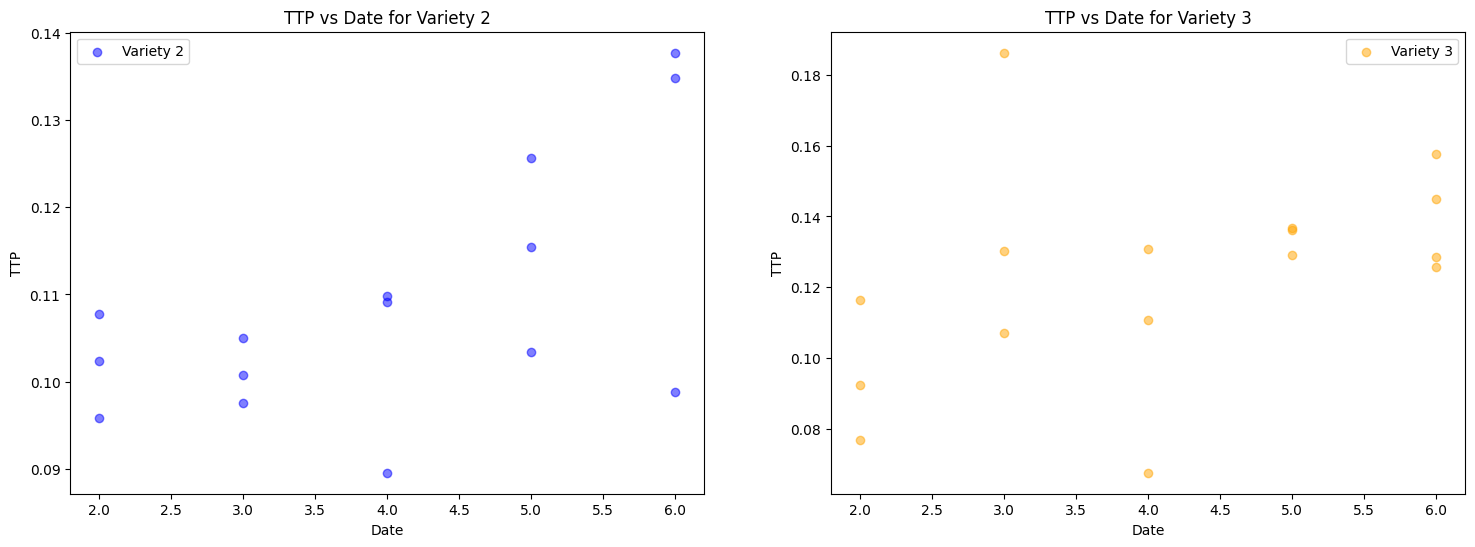

In [4]:
# plot TTP as a function of date per variety

ttp_v2 = labels[labels["variété"] == 2]
ttp_v3 = labels[labels["variété"] == 3]

fig, axes = plt.subplots(1,2, figsize=(18,6))
axes[0].scatter(ttp_v2["date"], ttp_v2["TTP"], c='blue', label='Variety 2', alpha=0.5)
axes[0].set_title('TTP vs Date for Variety 2')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('TTP')
axes[0].legend()
axes[1].scatter(ttp_v3["date"], ttp_v3["TTP"], c='orange', label='Variety 3', alpha=0.5)
axes[1].set_title('TTP vs Date for Variety 3')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('TTP')
axes[1].legend()
plt.show()

In [5]:
# construct a dataset 

labeled_dataset = labels.merge(data, how='left') # contains 186 spectra with labels
labeled_dataset

,variété,plant,date,mad,asiat,madAc,asiatAc,TTP,31,32,...,1442,1443,1444,1445,1446,1447,1448,1449,1450,1451
0,2.0,0.0,2.0,30.533333,30.30000,0.800000,34.133333,0.095767,0.121162,0.121638,...,0.371181,0.371924,0.372460,0.372671,0.372251,0.371135,0.370515,0.370751,0.371785,0.366851
1,2.0,0.0,2.0,30.533333,30.30000,0.800000,34.133333,0.095767,0.113444,0.117173,...,0.348572,0.348835,0.349107,0.348881,0.349221,0.349174,0.349393,0.350303,0.349765,0.341626
2,2.0,0.0,2.0,30.533333,30.30000,0.800000,34.133333,0.095767,0.105312,0.102119,...,0.370816,0.370548,0.370705,0.369965,0.369728,0.369999,0.369871,0.370293,0.371453,0.364542
3,2.0,0.0,2.0,30.533333,30.30000,0.800000,34.133333,0.095767,0.217925,0.211192,...,0.483035,0.483838,0.484641,0.484695,0.484899,0.484047,0.483582,0.483915,0.484282,0.477163
4,2.0,0.0,2.0,30.533333,30.30000,0.800000,34.133333,0.095767,0.082990,0.079520,...,0.323523,0.324134,0.324438,0.324587,0.324394,0.323738,0.323704,0.324499,0.325534,0.320852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,3.0,15.0,6.0,62.488457,58.67174,3.274382,33.207616,0.157642,0.168274,0.168730,...,0.384934,0.384972,0.385282,0.385732,0.385835,0.385435,0.385025,0.385230,0.385113,0.369203
182,3.0,15.0,6.0,62.488457,58.67174,3.274382,33.207616,0.157642,0.123538,0.122048,...,0.326021,0.325590,0.325456,0.325179,0.325153,0.324738,0.324317,0.324110,0.323493,0.311719
183,3.0,15.0,6.0,62.488457,58.67174,3.274382,33.207616,0.157642,0.095926,0.095074,...,0.311609,0.312030,0.311851,0.311292,0.310748,0.309498,0.309501,0.310566,0.311451,0.298718
184,3.0,15.0,6.0,62.488457,58.67174,3.274382,33.207616,0.157642,0.139649,0.142145,...,0.371725,0.371415,0.371053,0.371363,0.371459,0.371583,0.371930,0.371728,0.371653,0.355547


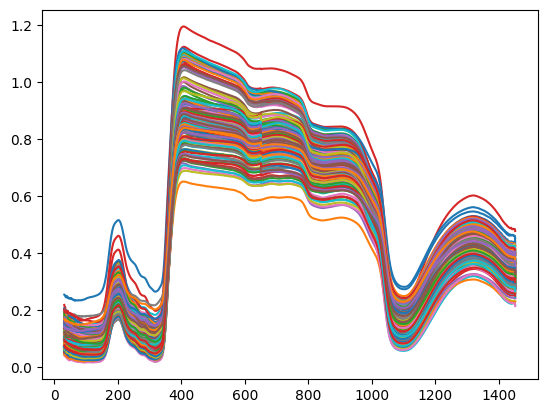

In [6]:
plt.plot(labeled_dataset[varlist].T)
plt.show()

In [7]:
labeled_dataset["sample"] = labeled_dataset.groupby(["variété", "plant"]).ngroup()
indexes = labeled_dataset["sample"].unique()


In [8]:
# découpage aléatoire en train et test suivvant 80/20, les individus (plantes) ne sont pas partagées entre train et test
from sklearn.model_selection import train_test_split

labeled_dataset["sample"] = labeled_dataset.groupby(["variété", "plant"]).ngroup()
indexes = labeled_dataset["sample"].unique()

train_indices, test_indices = train_test_split(indexes, test_size=0.2, random_state=42)

trainset = labeled_dataset[labeled_dataset["sample"].isin(train_indices)]
testset = labeled_dataset[labeled_dataset["sample"].isin(test_indices)]


In [9]:
# ANN models, the ones from Walsh and Cui and training and testing functions

from torch import nn
import torch.nn.functional as F
import csv
import datetime
import torcheval
from sklearn.metrics import r2_score

def train(model, optimizer, criterion, train_loader, val_loader, num_epochs, lr, device, save_path=None, scheduler=None, prompting=True):

    # model.to(device)

    if save_path:
        print("coucou1")
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
    final_save_path = save_path + f"/lr{str(lr).replace('.','')}_final.pth"

    print(save_path)
    with open(save_path + "/train_telemetry.csv", "a", newline='') as telemetrycsv:
        print("coucou")
        writer = csv.writer(telemetrycsv, delimiter=',', quoting=csv.QUOTE_MINIMAL)
        writer.writerow(['Date', 'Epoch', 'Train Losses', 'Validation Losses', 'Validation R2'])
    
    train_losses = []
    val_losses = []
    val_r2_scores = []
    
    min_val_loss = [0]

    for epoch in range(num_epochs):
        model.train()
        running_loss = torch.zeros(model.out_dims, device=device)
        for inputs, targets, idx in train_loader:
            
            inputs = inputs.to(device,non_blocking=True).float()
            targets = targets.to(device,non_blocking=True).float()

            optimizer.zero_grad()  # Zero the parameter gradients
            outputs = model(inputs[:,None])  # Forward pass
            loss = criterion(outputs, targets)  # Compute loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update weights
            running_loss += loss.item() * inputs.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        if scheduler :
            if not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step()
        train_losses.append(epoch_loss.detach())       
           
        # Validation loop
        model.eval()
        val_loss = torch.zeros(model.out_dims, device=device)
        out = []
        tar = []
        with torch.no_grad():
            for inputs, targets in val_loader:
               
                inputs = inputs.to(device,non_blocking=True).float()
                targets = targets.to(device,non_blocking=True).float()
                outputs = model(inputs[:,None])
                           
                loss = criterion(outputs, targets) 
                val_loss += loss.item() * inputs.size(0)
                
                out.append(outputs.detach())
                tar.append(targets.detach())


        val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(val_loss.detach().cpu())  
        if scheduler : 
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)  
        
        all_outputs = torch.cat(out, dim=0).cpu()
        all_targets = torch.cat(tar, dim=0).cpu()
        r2_scores = []
        f1_scores = []
        F1 = torcheval.metrics.MulticlassF1Score()
        F1.update(torch.argmax(all_outputs,dim=1),torch.argmax(all_targets,dim=1))
        f1_scores = F1.compute()

        train_loss_str = ', '.join([f'y {i}: {loss:.4f}' for i, loss in enumerate(epoch_loss)])
        val_loss_str = ', '.join([f'y {i}: {loss:.4f}' for i, loss in enumerate(val_loss)])
        r2_score_str = ', '.join([f'y {i}: {score:.4f}' for i, score in enumerate(r2_scores)])
        dt = datetime.datetime.now().strftime("%I:%M%p on %B %d, %Y")
        with open(save_path + "/train_telemetry.csv", "a", newline='') as telemetrycsv:
            writer = csv.writer(telemetrycsv, delimiter=',', quoting=csv.QUOTE_MINIMAL)
            writer.writerow([dt, epoch + 1, round(epoch_loss.detach().cpu().item(),4), round(val_loss.detach().cpu().item(),4), round(f1_scores[0].detach().cpu().item(),4)])
            if prompting : 
                print(f'Epoch {epoch + 1}/{num_epochs} | Train Losses: {train_loss_str} | Validation Losses: {val_loss_str}| F1 Score: {f1_scores}')
            

        # save best model via validation loss, and save path with best name
        # update the min_val_loss

        val = np.array(r2_scores)
        if save_path and (val.mean() > min_val_loss) and (val.mean() < 1.5) and (epoch + 1) > num_epochs*0.1  :
            min_val_loss = val.mean()
            torch.save(model.state_dict(), final_save_path)
            if prompting :
                print(f'Model saved at epoch {epoch + 1} to {final_save_path}')


    train_losses_np = [loss.cpu().numpy() for loss in train_losses]
    val_losses_np = [loss.cpu().numpy() for loss in val_losses]


    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotting Training and Validation Losses
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='tab:blue')
    ax1.set_ylim(top=5)
    ax1.plot(train_losses_np, label='Training Loss', color='tab:blue')
    ax1.plot(val_losses_np, label='Validation Loss', color='tab:orange')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.legend(loc='upper left')

    # Create another y-axis for R2 Scores
    ax2 = ax1.twinx()
    ax2.set_ylabel('R2 Score', color='tab:green')
    ax2.set_ylim(bottom=-1, top=1)

    # Assuming val_r2_scores is a list of lists (one list per epoch)
    for i in range(len(val_r2_scores[0])):  # Loop over each target dimension
        r2_scores = [scores[i] for scores in val_r2_scores]
        ax2.plot(r2_scores, label=f'R2 Score y{i}', linestyle='--', color='tab:green')

    ax2.tick_params(axis='y', labelcolor='tab:green')
    ax2.legend(loc='upper right')

    # Set title and layout
    plt.title('Training and Validation Metrics per Epoch')
    fig.tight_layout()  # To prevent overlapping

    # Show the plot
    # plt.show(block=False)
    plt.savefig(f"{save_path}/lr{str(lr).replace('.','')}_loss_plot.png")



    if save_path:
        return train_losses, val_losses, val_r2_scores , final_save_path
    else :
        return train_losses, val_losses, val_r2_scores

def RMSEP(y_true, y_pred):
    loss = np.sqrt(np.mean(np.square((y_true - y_pred)), axis=0))
    return loss

def ccc(y_true,y_pred):
    # Means
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)

    # Population variances
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)

    # Population standard deviations
    sd_true = np.std(y_true)
    sd_pred = np.std(y_pred)

    cor = np.corrcoef(y_true, y_pred,rowvar = False)[0][1]

    # Calculate CCC
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred)**2
    ccc = numerator / denominator
    return(ccc)


def test(model, model_path, test_loader,lr,classification=False,device = "cuda",save_path=None, prompting=True) :
    
    Y = []
    y_pred = []
    model.load_state_dict(torch.load(model_path))
    
    model.to(device)
    model.eval()
    with torch.no_grad():
        for inputs, targets in test_loader:
            Y.append(targets.to("cpu").numpy())
            inputs = inputs.to(device,non_blocking=True).float()
            y_pred.append(model(inputs[:,None]).to("cpu").numpy())
    Y = np.concatenate(Y)
    y_pred = np.concatenate(y_pred)


    ccc_score = ccc(y_pred,Y)
    r2_score_ = r2_score( Y,y_pred)
    rmsep_score = RMSEP(y_pred, Y)[0]
    if prompting:
        print(f"CCC: {ccc_score}, R2: {r2_score_}, RMSEP: {rmsep_score}")

        plt.figure(figsize=(8,6))

        # Scatter plot of X vs Y
        plt.scatter(Y,y_pred,edgecolors='k',alpha=0.5)

        # Plot of the 45 degree line
        plt.plot([Y.min()-1,Y.max()+1],[Y.min()-1,Y.max()+1],'r')
        # add text with cc_score and r2_score
        plt.text(0.95, 0.05, f'CCC: {ccc_score:.2f}\nR²: {r2_score_:.2f}\nRMSEP: {rmsep_score:.2f}',
            transform=plt.gca().transAxes, fontsize=12,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'),
            color='red', fontweight='bold', fontfamily='serif')

        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.xlabel('Observed',fontsize=16)
        plt.ylabel('Predicted',fontsize=16)
        plt.title(f'Predicted vs Observed',fontsize=16)
        # plt.show(block=False)
        plt.savefig(f"{save_path}/lr{str(lr).replace('.','')}_test_plot.png")

    return ccc_score, r2_score_.item(), rmsep_score.item()

class AndersonANN(nn.Module):
    def __init__(self, input_dims, mean, std, out_dims):
        super(AndersonANN, self).__init__()
        self.input_dims = input_dims
        self.out_dims = out_dims
        self.nb_neurons = 5
        self.fc1 = nn.Linear(self.input_dims, self.nb_neurons)
        self.fc2 = nn.Linear(self.nb_neurons, self.out_dims)
        self.mean = nn.Parameter(torch.tensor(mean).float(),requires_grad=False)
        self.std = nn.Parameter(torch.tensor(std).float(),requires_grad=False)

    def forward(self, x):
        x = (x-self.mean)/self.std
        x = F.sigmoid(self.fc1(x))
        x = self.fc2(x)
        return torch.reshape(x, (x.shape[0],1))
    

class CuiNet(nn.Module):
    def __init__(self, input_dims, mean,std,dropout=0.,out_dims=1,kinit="nokinit"):
        super(CuiNet, self).__init__()
        
        # Layers dimensions
        self.k_width = 5
        self.conv1d_dims = input_dims-(self.k_width-1)         # size of spectrum - (kernel_size-1) is the size of the spectrum after first conv1D
        self.k_stride = 1
        self.fc1_dims = 36
        self.fc2_dims = 18
        self.fc3_dims = 12
        self.out_dims = out_dims
        self.dropout= nn.Dropout(dropout)
        self.mean = nn.Parameter(torch.tensor(mean).float(),requires_grad=False)
        self.std = nn.Parameter(torch.tensor(std).float(),requires_grad=False)
        
        # Convolutional layer
        self.conv1d = nn.Conv1d(1,1, kernel_size= 5 , stride=1)
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.conv1d_dims, self.fc1_dims)
        self.fc2 = nn.Linear(self.fc1_dims, self.fc2_dims)
        self.fc3 = nn.Linear(self.fc2_dims, self.fc3_dims)
        self.out = nn.Linear(self.fc3_dims, self.out_dims)
        
        # Initialize weights with He normal
        if kinit == "kinit":
            self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        # Reshape input
        x = (x-self.mean)/self.std
        # Convolutional layer with ELU activation
        x = F.elu(self.conv1d(x))
        
        # Flatten the output from conv1d
        x = x.view(x.size(0), -1)
        
        # Fully connected layers with ELU activation
        x = F.elu(self.fc1(x))
        x = F.elu(self.fc2(x))
        x = F.elu(self.fc3(x))
        x = self.dropout(x)
        
        # Output layer with linear activation
        x = self.out(x)
        return x

In [10]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import ShuffleSplit
from tqdm import tqdm

In [11]:
x = trainset[varlist].values
y = trainset["TTP"].values

cv = ShuffleSplit(n_splits=30, test_size=0.5, random_state=0)

results_cv = []
results = []
for i in tqdm(range(50)):
    pls = PLSRegression(n_components=i+1)
    results_cv.append(np.mean(cross_val_score(pls, x, y, cv=cv, scoring='r2')))
    pls.fit(x,y)
    results.append(r2_score(y, pls.predict(x)))


100%|██████████| 50/50 [02:07<00:00,  2.54s/it]


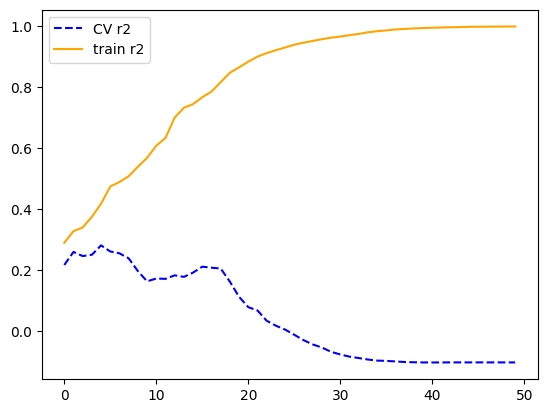

In [12]:
plt.plot(results_cv, color='blue', label='CV r2', linestyle='--')
plt.plot(results, color='orange', label='train r2')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Predicted vs Observed, PLS with 1 compnents')

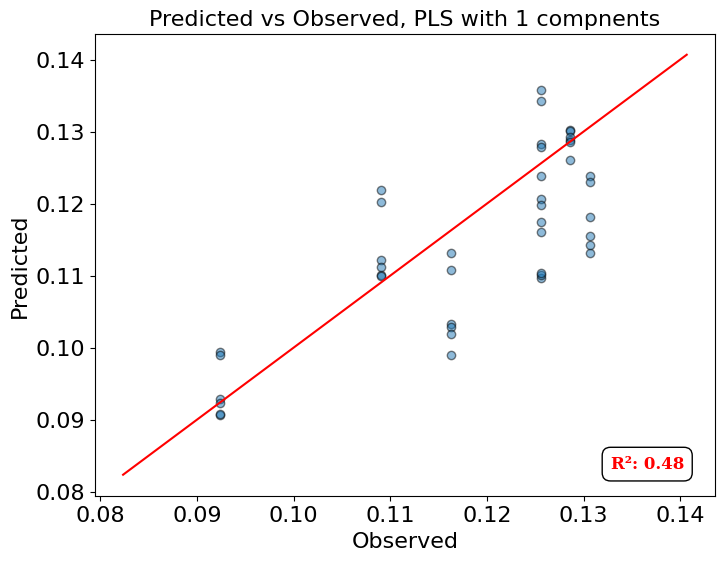

In [16]:
# nb_comp = np.argmax(results_cv) +1
nb_comp = 1
pls_finale = PLSRegression(1)
pls_finale.fit(x,y)

x_test = testset[varlist].values
y_test = testset["TTP"].values

y_test_pred = pls_finale.predict(x_test)

r2_score_ = r2_score(y_test, y_test_pred)

plt.figure(figsize=(8,6))

# Scatter plot of X vs Y
plt.scatter(y_test,y_test_pred,edgecolors='k',alpha=0.5)

# Plot of the 45 degree line
plt.plot([y_test.min()-0.01,y_test.max()+0.01],[y_test.min()-0.01,y_test.max()+0.01],'r')
# add text with cc_score and r2_score
plt.text(0.95, 0.05, f'R²: {r2_score_:.2f}',
    transform=plt.gca().transAxes, fontsize=12,
    verticalalignment='bottom', horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'),
    color='red', fontweight='bold', fontfamily='serif')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Observed',fontsize=16)
plt.ylabel('Predicted',fontsize=16)
plt.title(f'Predicted vs Observed, PLS with {nb_comp} compnents',fontsize=16)

### Try by augmenting the dataset

In [17]:
from abc import ABC, abstractmethod
from sklearn.decomposition import PCA

def replicates_local(x_train_df):
    replicates_means = []
    samples = []
    for idx in x_train_df["sample"].unique():
        replicates = x_train_df[x_train_df["sample"]==idx][varlist].to_numpy()
        if len(replicates) > 2 :
            samples.append(replicates)
            replicates_means.append(np.mean(replicates, axis=0))

    differences = []
    for i in range(len(replicates_means)):
        for j in range(len(samples[i])):
            differences.append(replicates_means[i]-samples[i][j])
    differences = np.array(differences)

    return x_train_df.drop(columns=["sample"]), differences
    
class Generator(ABC):
    @abstractmethod
    def generate_residues(self,nb:int,loadings,scores,mean_residues):
        pass

class LocalGaussianGeneratorWithScores(Generator):
    def __init__(self, loadings, scores, residues_mean, alpha:float=0.1):
        super().__init__()
        self.loadings = loadings
        self.residues_mean = residues_mean
        self.scores = scores
        self.scores_std = np.std(scores,axis=0)
        self.alpha=alpha
        
    def generate_residues(self, idx):
        deviations = np.random.normal(loc=0, scale=(self.alpha*self.scores_std), size=(len(idx), self.scores.shape[1]))
        new_scores = self.scores[idx,:] + deviations
        residues = np.matmul(new_scores,self.loadings) + self.residues_mean
        return residues

In [18]:
trainset.reset_index(inplace=True)

In [19]:
indices = list(range(len(trainset)))

In [51]:
cal_features, residues = replicates_local(trainset)
pca = PCA(n_components=100)
pca.fit(residues)
loadings = pca.components_
scores = pca.transform(residues)
mean_residues = np.mean(residues, axis=0)
generator = LocalGaussianGeneratorWithScores(loadings,scores,mean_residues,1.)

In [52]:
originals = trainset[varlist].values

mul_factor = 4
aug_list = []

for i in range(mul_factor):
    transforms = originals + generator.generate_residues(indices)
    new_df = pd.DataFrame(transforms, columns=varlist)
    new_df["index"] = trainset["index"]
    new_df["variété"] = trainset["variété"]
    new_df["plant"] = trainset["plant"]
    new_df["date"] = trainset["date"]
    new_df["mad"] = trainset["mad"]
    new_df["asiat"] = trainset["asiat"]
    new_df["madAc"] = trainset["madAc"]
    new_df["asiatAc"] = trainset["asiatAc"]
    new_df["TTP"] = trainset["TTP"]
    aug_list.append(new_df)

augmented_trainset = pd.concat(aug_list, ignore_index=True)
augmented_trainset

,31,32,33,34,35,36,37,38,39,40,...,1451,index,variété,plant,date,mad,asiat,madAc,asiatAc,TTP
0,0.143313,0.143141,0.141788,0.137122,0.127064,0.123984,0.123370,0.121016,0.121895,0.125486,...,0.372311,0,2.0,0.0,2.0,30.533333,30.30000,0.800000,34.133333,0.095767
1,0.135924,0.133430,0.130065,0.127912,0.121089,0.120794,0.120503,0.116253,0.119289,0.119056,...,0.353322,1,2.0,0.0,2.0,30.533333,30.30000,0.800000,34.133333,0.095767
2,0.094905,0.092652,0.091100,0.091242,0.086127,0.082579,0.081754,0.082690,0.082376,0.080659,...,0.344903,2,2.0,0.0,2.0,30.533333,30.30000,0.800000,34.133333,0.095767
3,0.104306,0.100454,0.098888,0.099692,0.092058,0.088315,0.088281,0.088757,0.085132,0.084480,...,0.363604,3,2.0,0.0,2.0,30.533333,30.30000,0.800000,34.133333,0.095767
4,0.154728,0.152930,0.151077,0.149285,0.142869,0.141301,0.140254,0.136327,0.135092,0.134730,...,0.419272,4,2.0,0.0,2.0,30.533333,30.30000,0.800000,34.133333,0.095767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,0.129818,0.127580,0.123770,0.122253,0.123288,0.126232,0.125993,0.121452,0.122598,0.122538,...,0.294141,181,3.0,15.0,6.0,62.488457,58.67174,3.274382,33.207616,0.157642
572,0.132724,0.128989,0.127918,0.129200,0.125873,0.128684,0.131075,0.128374,0.128107,0.127342,...,0.325968,182,3.0,15.0,6.0,62.488457,58.67174,3.274382,33.207616,0.157642
573,0.157235,0.154886,0.147029,0.139874,0.142301,0.145486,0.146839,0.145936,0.143836,0.141596,...,0.395640,183,3.0,15.0,6.0,62.488457,58.67174,3.274382,33.207616,0.157642
574,0.136431,0.141621,0.140609,0.133788,0.130856,0.132673,0.133578,0.130172,0.127387,0.126710,...,0.350393,184,3.0,15.0,6.0,62.488457,58.67174,3.274382,33.207616,0.157642


In [46]:
x_aug = augmented_trainset[varlist].values
y_aug = augmented_trainset["TTP"].values

cv = ShuffleSplit(n_splits=30, test_size=0.75, random_state=0)

results_cv_aug = []
results_aug = []
for i in tqdm(range(50)):
    pls = PLSRegression(n_components=i+1)
    results_cv_aug.append(np.mean(cross_val_score(pls, x_aug, y_aug, cv=cv, scoring='r2')))
    pls.fit(x_aug,y_aug)
    results_aug.append(r2_score(y_aug, pls.predict(x_aug)))

100%|██████████| 50/50 [01:52<00:00,  2.25s/it]


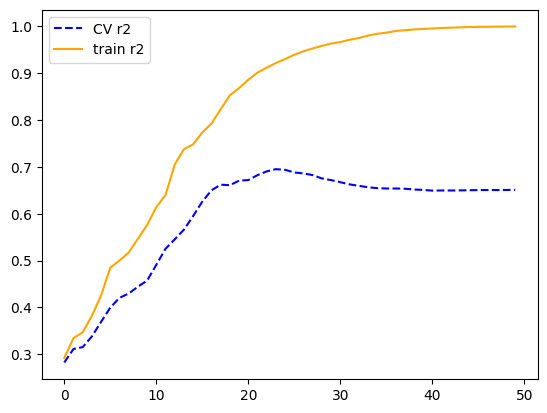

In [47]:
plt.plot(results_cv_aug, color='blue', label='CV r2', linestyle='--')
plt.plot(results_aug, color='orange', label='train r2')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Predicted vs Observed, PLS with 6 compnents')

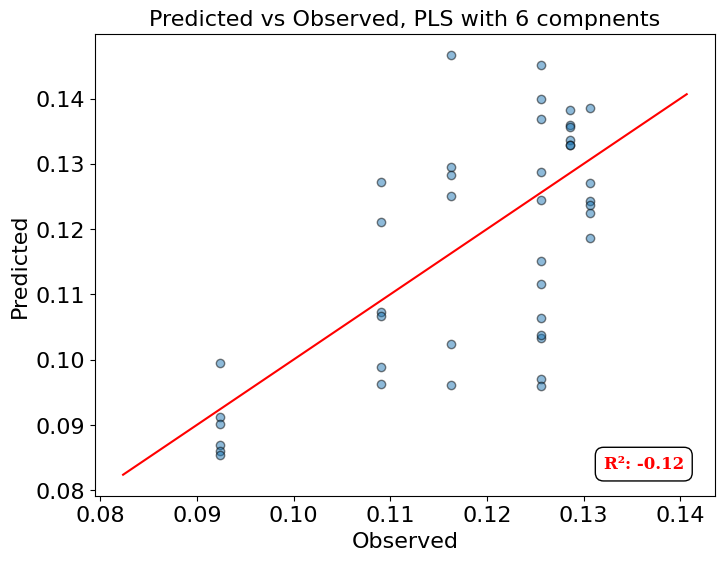

In [ ]:
nb_comp = np.argmax(results_cv)+1
pls_finale = PLSRegression(n_components=nb_comp)
pls_finale.fit(x,y)

x_test = testset[varlist].values
y_test = testset["TTP"].values

y_test_pred = pls_finale.predict(x_test)

r2_score_ = r2_score(y_test, y_test_pred)

plt.figure(figsize=(8,6))

# Scatter plot of X vs Y
plt.scatter(y_test,y_test_pred,edgecolors='k',alpha=0.5)

# Plot of the 45 degree line
plt.plot([y_test.min()-0.01,y_test.max()+0.01],[y_test.min()-0.01,y_test.max()+0.01],'r')
# add text with cc_score and r2_score
plt.text(0.95, 0.05, f'R²: {r2_score_:.2f}',
    transform=plt.gca().transAxes, fontsize=12,
    verticalalignment='bottom', horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'),
    color='red', fontweight='bold', fontfamily='serif')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Observed',fontsize=16)
plt.ylabel('Predicted',fontsize=16)
plt.title(f'Predicted vs Observed, PLS with {nb_comp+1} compnents',fontsize=16)

### Test comme Daphné (présupossément)

In [57]:
x = labeled_dataset[varlist].values
y = labeled_dataset["TTP"].values

cv = ShuffleSplit(n_splits=30, test_size=0.5, random_state=0)

results_cv = []
results = []
for i in tqdm(range(50)):
    pls = PLSRegression(n_components=i+1)
    results_cv.append(np.mean(cross_val_score(pls, x, y, cv=cv, scoring='r2')))
    pls.fit(x,y)
    results.append(r2_score(y, pls.predict(x)))

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [01:11<00:00,  1.42s/it]


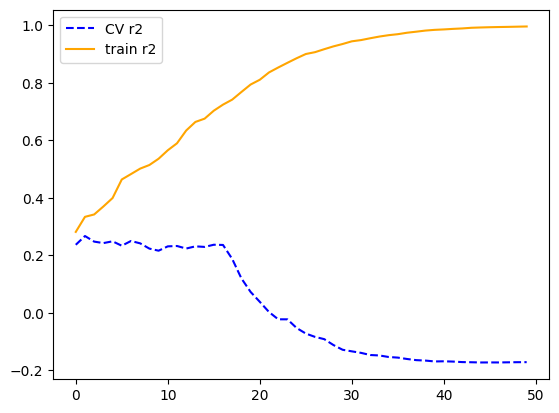

In [58]:
plt.plot(results_cv, color='blue', label='CV r2', linestyle='--')
plt.plot(results, color='orange', label='train r2')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Predicted vs Observed, PLS with 3 compnents')

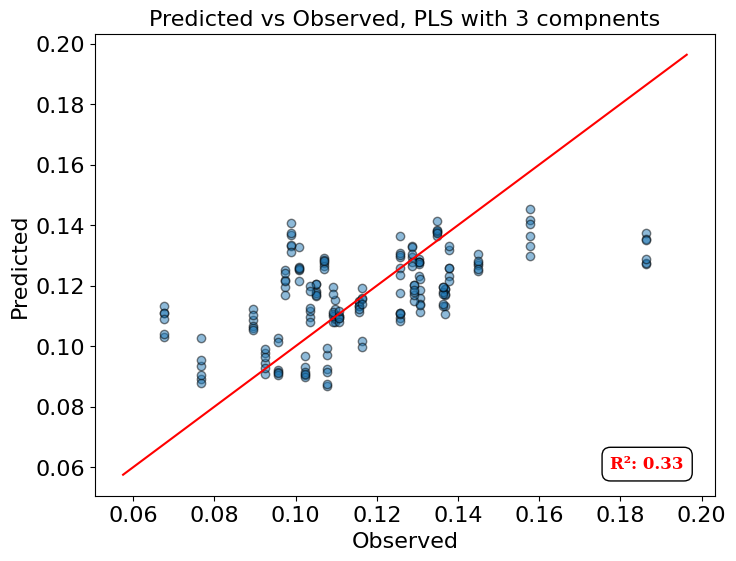

In [65]:
nb_comp = np.argmax(results_cv)+1
pls_finale = PLSRegression(n_components=nb_comp)
pls_finale.fit(x,y)

x_test = labeled_dataset[varlist].values
y_test = labeled_dataset["TTP"].values

y_test_pred = pls_finale.predict(x_test)

r2_score_ = r2_score(y_test, y_test_pred)

plt.figure(figsize=(8,6))

# Scatter plot of X vs Y
plt.scatter(y_test,y_test_pred,edgecolors='k',alpha=0.5)

# Plot of the 45 degree line
plt.plot([y_test.min()-0.01,y_test.max()+0.01],[y_test.min()-0.01,y_test.max()+0.01],'r')
# add text with cc_score and r2_score
plt.text(0.95, 0.05, f'R²: {r2_score_:.2f}',
    transform=plt.gca().transAxes, fontsize=12,
    verticalalignment='bottom', horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'),
    color='red', fontweight='bold', fontfamily='serif')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Observed',fontsize=16)
plt.ylabel('Predicted',fontsize=16)
plt.title(f'Predicted vs Observed, PLS with {nb_comp+1} compnents',fontsize=16)